<a href="https://colab.research.google.com/github/zahradhitaaisyahputri/Tugas_05_Logistic_regression/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Anggota Kelompok :**
1. Zahra Dhita Aisyah Putri (24523262)
2. Sifa Aulia Aroyaningrum (24523078)
3. Siti Hajar (23523248)

## 1. Preprocessing Data yang Diperlukan

In [ ]:
import numpy as np
import pandas as pd # Import pandas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# --- BEGIN MODIFICATION: Added data loading step ---
import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")

print("Path to dataset files:", path)

# Assuming the dataset is a CSV file within the downloaded path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)
    print(f"Loaded dataset from: {data_file_path}")
else:
    print("No CSV file found in the downloaded directory.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later

# Display the first 5 rows of the DataFrame
display(df.head())
# --- END MODIFICATION ---

# Separate features (X) and target (y)
X = df.drop('TenYearCHD', axis=1) # Corrected target variable
y = df['TenYearCHD']              # Corrected target variable

# Handle missing values if any. For simplicity, we'll fill with the mode for now,
# especially for 'ca' and 'thal' which might have categorical-like values and missing entries.
# Inspecting the data often reveals '?' or similar as missing, so converting to NaN first.
X = X.replace('?', np.nan)

# Impute missing numerical values with the mean and categorical with the mode
for column in X.columns:
    if X[column].dtype == 'object' or column in ['ca', 'thal']:
        # Convert to numeric if possible, coerce errors to NaN for better imputation
        X[column] = pd.to_numeric(X[column], errors='coerce')
        if X[column].isnull().any():
            # Impute with mode for categorical/ordinal features like 'ca', 'thal'
            mode_val = X[column].mode()[0]
            X[column] = X[column].fillna(mode_val) # Fixed inplace warning
    elif X[column].isnull().any():
        # Impute with mean for other numerical features
        X[column] = X[column].fillna(X[column].mean()) # Fixed inplace warning


# Identify categorical columns for one-hot encoding
# Based on common understanding of this dataset, many columns are categorical/ordinal
# The previous categorical_cols list contained columns not present in framingham.csv
# For this dataset, binary features like 'male', 'currentSmoker', 'BPMeds', etc.,
# can be used directly as numerical features without one-hot encoding.
# 'education' is ordinal and can also be treated numerically.
# No other clear multi-category nominal features are present in the provided df.head().
categorical_cols = []

# Ensure 'ca' and 'thal' are treated as numerical after imputation, but if they were objects, handle them.
# Given the dataset, 'ca' and 'thal' are not present. Removing the conditional check for 'ca' as it's not in this dataset.

# Perform one-hot encoding for identified categorical features (will be skipped if list is empty)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

display(X.head())

Using Colab cache for faster access to the 'heart-disease-prediction-using-logistic-regression' dataset.
Path to dataset files: /kaggle/input/heart-disease-prediction-using-logistic-regression
Loaded dataset from: /kaggle/input/heart-disease-prediction-using-logistic-regression/framingham.csv


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


### 2. Pembagian Data Training dan Testing

In [ ]:
# Split the data into training and testing sets
# We'll use a 70/30 split, which is a common practice.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2966, 15)
Shape of X_test: (1272, 15)
Shape of y_train: (2966,)
Shape of y_test: (1272,)


## 3. Membangun Model Logistic Regression dan Membuat Prediksi

In [ ]:
# Create a logistic regression model instance
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Train the model with the training data
model.fit(X_train, y_train)

# Get the model's coefficients and intercept
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

# You can convert the coefficients to odds ratios by exponentiating them
odds_ratio = np.exp(model.coef_)
print(f"Odds Ratio: {odds_ratio}")
# Note: Interpreting odds ratios for one-hot encoded features requires looking at the specific feature.


Intercept: [-5.11268288]
Coefficients: [[ 3.61895982e-01  5.32314305e-02 -3.57610319e-02 -1.12775133e-01
   2.29342443e-02  3.16747184e-01  6.60934950e-01  4.28438457e-01
   1.16489161e-01 -6.10044754e-04  1.13888359e-02 -4.82646685e-03
  -2.40105226e-02 -1.06364780e-02  8.12346789e-03]]
Odds Ratio: [[1.43604956 1.0546737  0.96487084 0.89335152 1.02319926 1.3726555
  1.93660211 1.5348589  1.12354533 0.99939014 1.01145394 0.99518516
  0.97627544 0.98941989 1.00815655]]


In [ ]:
# Predict the class labels for the test set
y_pred = model.predict(X_test)
print(f"Predicted labels (first 10): {y_pred[:10]}")

# Predict the probability of each class
y_pred_proba = model.predict_proba(X_test)
print(f"Predicted probabilities (first 10 rows):\n {y_pred_proba[:10]}")

Predicted labels (first 10): [0 0 0 0 0 0 0 0 0 1]
Predicted probabilities (first 10 rows):
 [[0.64287991 0.35712009]
 [0.92194711 0.07805289]
 [0.89169635 0.10830365]
 [0.85518846 0.14481154]
 [0.93311044 0.06688956]
 [0.84475166 0.15524834]
 [0.92537877 0.07462123]
 [0.83790583 0.16209417]
 [0.82583319 0.17416681]
 [0.48562805 0.51437195]]


## 4. Evaluasi Model

In [ ]:
# Generate a classification report
# This report shows the precision, recall, f1-score, and support for each class.
class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92      1084
           1       0.76      0.09      0.15       188

    accuracy                           0.86      1272
   macro avg       0.81      0.54      0.54      1272
weighted avg       0.85      0.86      0.81      1272



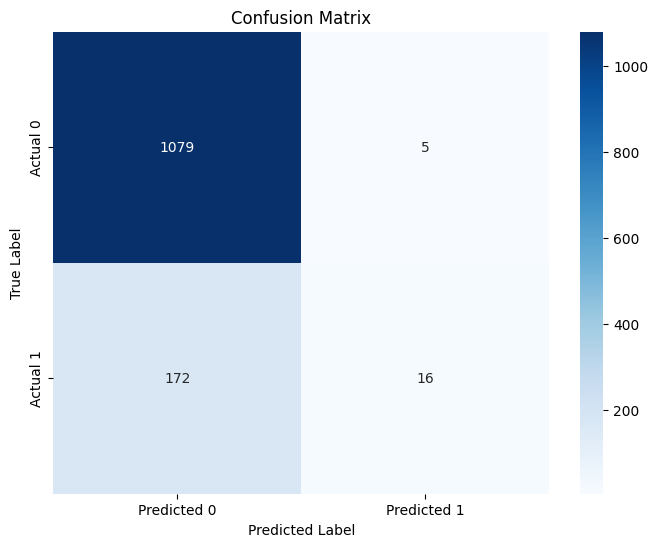

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 5. Tampilkan beberapa contoh hasil prediksi (y_pred) dan bandingkan dengan label sebenarnya (y_test).

In [ ]:
import pandas as pd

# Create a DataFrame to compare actual vs. predicted labels
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Filter to show only cases where the actual label is 1
comparison_df_filtered = comparison_df[comparison_df['Actual'] == 1]

# Display the first few rows of the filtered comparison
print("Comparison of Actual vs. Predicted Labels where Actual is 1 (first 20 samples):")
display(comparison_df_filtered.head(20))

Comparison of Actual vs. Predicted Labels where Actual is 1 (first 20 samples):


,Actual,Predicted
2333,1,0
1674,1,1
2917,1,0
889,1,0
1714,1,0
238,1,0
1741,1,0
3334,1,0
1832,1,0
305,1,0


### 6. Pertanyaan :
### Analisis Kinerja Model Berdasarkan Classification Report dan Konteks Medis

#### 1. Kinerja Model Berdasarkan Classification Report:
*   **Akurasi Keseluruhan (Accuracy):** Model mencapai akurasi sekitar **86%**. Ini berarti 86% dari semua prediksi (baik positif maupun negatif) adalah benar.
*   **Kinerja untuk Kelas 0 (Tidak Ada Penyakit Jantung):**
    *   **Recall (Sensitivitas): 1.00 (100%)**. Ini sangat tinggi, menunjukkan bahwa model berhasil mengidentifikasi hampir semua kasus di mana pasien *tidak memiliki* penyakit jantung. Tidak ada kasus 'Tidak ada penyakit jantung' yang terlewatkan.
    *   **Precision: 0.86**. Ini berarti 86% dari prediksi model bahwa pasien 'tidak memiliki' penyakit jantung adalah benar.
*   **Kinerja untuk Kelas 1 (Ada Penyakit Jantung):**
    *   **Recall (Sensitivitas): 0.09 (9%)**. Ini sangat rendah, yang merupakan masalah serius. Ini berarti model hanya berhasil mengidentifikasi 9% dari semua pasien yang *sebenarnya memiliki* penyakit jantung. Sebagian besar kasus penyakit jantung tidak terdeteksi oleh model.
    *   **Precision: 0.76**. Ini berarti 76% dari prediksi model bahwa pasien 'memiliki' penyakit jantung adalah benar. Meskipun presisi cukup baik, rendahnya recall menunjukkan bahwa model jarang membuat prediksi positif, sehingga ketika itu terjadi, prediksinya cenderung benar.

Secara keseluruhan, model memiliki bias kuat untuk memprediksi kelas mayoritas (tidak ada penyakit jantung), yang mengakibatkan akurasi yang tinggi tetapi kinerja yang sangat buruk dalam mendeteksi kelas minoritas (penyakit jantung).

#### 2. Makna True Positive (TP), False Positive (FP), True Negative (TN), dan False Negative (FN) pada Studi Kasus Prediksi Penyakit Jantung:
*   **True Positive (TP):** Model memprediksi **ada penyakit jantung**, dan pasien **memang benar-benar memiliki penyakit jantung**.
*   **False Positive (FP):** Model memprediksi **ada penyakit jantung**, tetapi pasien **sebenarnya tidak memiliki penyakit jantung** (ini adalah 'alarm palsu').
*   **True Negative (TN):** Model memprediksi **tidak ada penyakit jantung**, dan pasien **memang benar-benar tidak memiliki penyakit jantung**.
*   **False Negative (FN):** Model memprediksi **tidak ada penyakit jantung**, tetapi pasien **sebenarnya memiliki penyakit jantung** (ini adalah 'deteksi yang terlewatkan', dan seringkali merupakan kesalahan yang paling berbahaya dalam konteks medis).

#### 3. Kesimpulan Mengenai Seberapa Baik Logistic Regression Bekerja pada Dataset yang Digunakan:
Berdasarkan `classification_report`, model Logistic Regression ini **tidak bekerja dengan baik** untuk tujuan praktis mendeteksi penyakit jantung. Meskipun akurasi keseluruhan 86% terlihat menjanjikan, ini sangat menyesatkan karena sebagian besar berasal dari kemampuan model yang sangat baik dalam mengidentifikasi individu yang *tidak memiliki* penyakit jantung (Recall 1.00 untuk Kelas 0).

Masalah utamanya adalah **rendahnya Recall untuk Kelas 1 (penyakit jantung), yaitu hanya 9%**. Ini berarti model gagal mendeteksi sebagian besar kasus penyakit jantung yang sebenarnya ada. Dalam konteks medis, kesalahan False Negative (tidak mendeteksi penyakit padahal ada) bisa sangat berbahaya. Oleh karena itu, model ini perlu ditingkatkan secara signifikan, kemungkinan dengan menangani ketidakseimbangan kelas (class imbalance) dalam dataset atau mencoba algoritma klasifikasi lainnya.